## NovaGen Research Labs

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

## Creating a Baseline Model

In [2]:
df = pd.read_csv("novagen_dataset.csv")

# Split features and target
X = df.drop("Target", axis=1)
y = df["Target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# Logistic Regression (with Regulaization)
log_reg = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

# In Model Evaluation, Recall is more important than accuracy 
# because missing a high-risk patient is dangerous

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Recall:", recall_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8141361256544503
Logistic Regression Recall: 0.8283132530120482
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       914
           1       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910



## Model 2 - KNN

In [5]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Recall:", recall_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8832460732984293
KNN Recall: 0.8835341365461847
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       914
           1       0.89      0.88      0.89       996

    accuracy                           0.88      1910
   macro avg       0.88      0.88      0.88      1910
weighted avg       0.88      0.88      0.88      1910



## Random Forest (Ensemble Learning)

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9382198952879581
Random Forest Recall: 0.9588353413654619
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       914
           1       0.93      0.96      0.94       996

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910



## Gradient Boosting (Ensemble Learning)

In [7]:
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Recall:", recall_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9303664921465968
Gradient Boosting Recall: 0.9497991967871486
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       914
           1       0.92      0.95      0.93       996

    accuracy                           0.93      1910
   macro avg       0.93      0.93      0.93      1910
weighted avg       0.93      0.93      0.93      1910



## Voting Classifier (Ensemble Learning)

In [8]:
voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, solver="liblinear")),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42))
    ],
    voting="soft"
)

voting_clf.fit(X_train_scaled, y_train)

y_pred_vote = voting_clf.predict(X_test_scaled)

print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_vote))
print("Voting Classifier Recall:", recall_score(y_test, y_pred_vote))
print(classification_report(y_test, y_pred_vote))


Voting Classifier Accuracy: 0.9157068062827225
Voting Classifier Recall: 0.929718875502008
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       914
           1       0.91      0.93      0.92       996

    accuracy                           0.92      1910
   macro avg       0.92      0.92      0.92      1910
weighted avg       0.92      0.92      0.92      1910



## Results

| Model                | Recall |
|----------------------|:------:|
| Logistic Regression  | 82.8%  |
| KNN                  | 88.3%  |
| Random Forest        | 95.8%  |
| Gradient Boosting    | 94.9%  |
| Voting Classifier    | 93.07% |

### Best Classifier that we should use for NovaGen(based on Recall) - Random Forest with accuracy of 93.7%

In [9]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="recall"
)

print("5-Fold Cross Validation Recall:")
print(cv_scores)

print("Mean Recall:", cv_scores.mean())

5-Fold Cross Validation Recall:
[0.95226131 0.95859473 0.94604768 0.94604768 0.93341709]
Mean Recall: 0.9472736959578318


Confusion Matrix:
[[837  77]
 [ 41 955]]


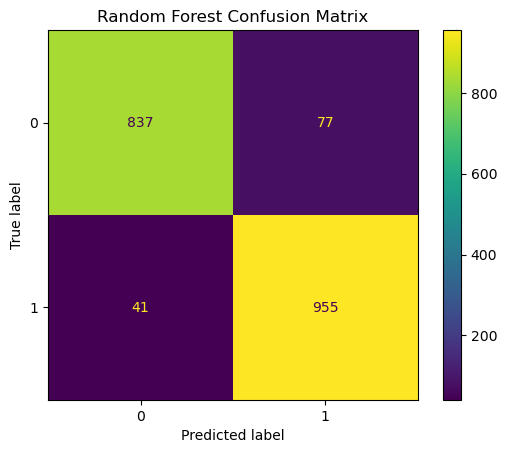

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

Random Forest ROC-AUC: 0.9844091903719914


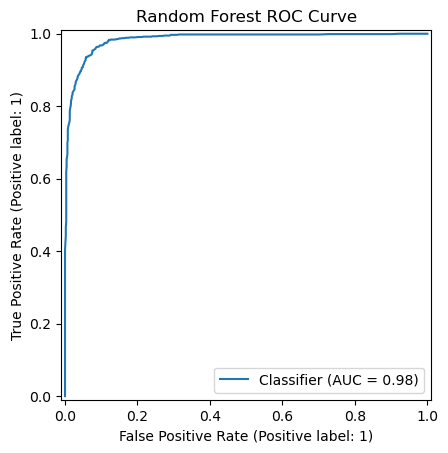

In [11]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_prob = rf.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)

print("Random Forest ROC-AUC:", auc_score)

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Random Forest ROC Curve")
plt.show()

Feature Importance:
BMI                      0.209735
Blood_Pressure           0.158685
Cholesterol              0.108142
Stress_Level             0.085640
Glucose_Level            0.072369
Sleep_Hours              0.069404
Age                      0.067378
Heart_Rate               0.049491
Water_Intake             0.048155
Exercise_Hours           0.026469
Smoking                  0.011176
MentalHealth             0.011052
Allergies                0.011038
PhysicalActivity         0.010952
Alcohol                  0.010874
MedicalHistory           0.010831
Diet                     0.010544
Diet_Type__Vegan         0.005934
Blood_Group_B            0.005618
Blood_Group_O            0.005542
Diet_Type__Vegetarian    0.005496
Blood_Group_AB           0.005473
dtype: float64


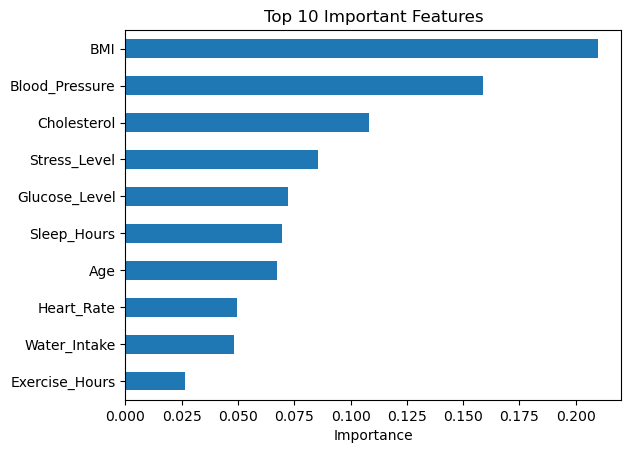

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [13]:
import joblib

joblib.dump(rf, "novagen_random_forest.pkl")
joblib.dump(scaler, "novagen_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
